## Figure 5: Phosphoproteomics indicate differential effects of mutation across race, indicate dysregulation in CDK1/AURKB relationship

In [1]:
# Disable logging
import warnings
warnings.simplefilter('ignore')

In [2]:
# Load R magic for Jupyter cells
%load_ext rpy2.ipython

In [3]:
# Add Python repository to path
import sys
sys.path.append("../../src/python")

In [4]:
import os
from os.path import abspath, dirname, exists, join

import matplotlib.pyplot as plt
import pandas as pd
from pilot.data_import import import_meta, import_phospho
from pilot.figures.figure_setup import get_setup

REPO_PATH = join(dirname(dirname(abspath(os.getcwd()))))

### Subfigure 5a: Kinase Enrichment Analysis
First, we'll examine the phosphoproteomic measurements to see if there's indication of differences in kinase activity. We'll start by setting-up data directories and moving measurements to the R directories--since we're performing multiple comparisons, building one runner function is less feasible, so we'll run everything in R here (opposed figure 2).

In [5]:
# Import data, setup results storage in R
meta = import_meta()
phospho = pd.concat(import_phospho())
os.makedirs(join(REPO_PATH, "src", "r", "ksea_mutations", "results"), exist_ok=True)

# Store data where R can find it
if not exists(join(REPO_PATH, "src", "r", "ksea_mutations", "phospho.csv")):
    phospho.to_csv(
        join(
            REPO_PATH,
            "src",
            "r",
            "ksea_mutations",
            "phospho.csv"
        )
    )
    meta.to_csv(
        join(
            REPO_PATH,
            "src",
            "r",
            "ksea_mutations",
            "meta.csv"
        )
    )

[syn75382181:phospho_beataml_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_beataml_batch_corrected_global_adjust.csv, skipping download.
[syn75382183:phospho_pilot_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_pilot_batch_corrected_global_adjust.csv, skipping download.


In [6]:
%%R
source("../../src/r/ksea_mutations/run_ksea_mutations.R")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    Welcome, JLChin!

[syn73849653:psp_2023_ks_data.csv]: Found existing file at /Users/jackson.chin/.synapseCache/867/169440867/psp_2023_ks_data.csv, skipping download.
Coefficients not estimable: StudypilotStudy 
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: ggplot2
Loading required package: ggrepel
here() starts at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities

New synapser version detected:
    You are using synapser version 2.0.0.200.
    synapser version 2.1.5.356 is detected at http://ran.synapse.org.
    To upgrade to the latest version of synapser, please run the following command:
    install.packages("synapser", repos="http://ran.synapse.org")


TERMS OF USE NOTICE:
  When using Synapse, remember that the terms and conditions of use require that you:
  1) Attribute data contributors when discussing these data or results from these data.
  2) Not discriminate, identify, or recontact individuals or groups represented by the data.
  3) Use and contribute only data de-identified to HIPAA standa

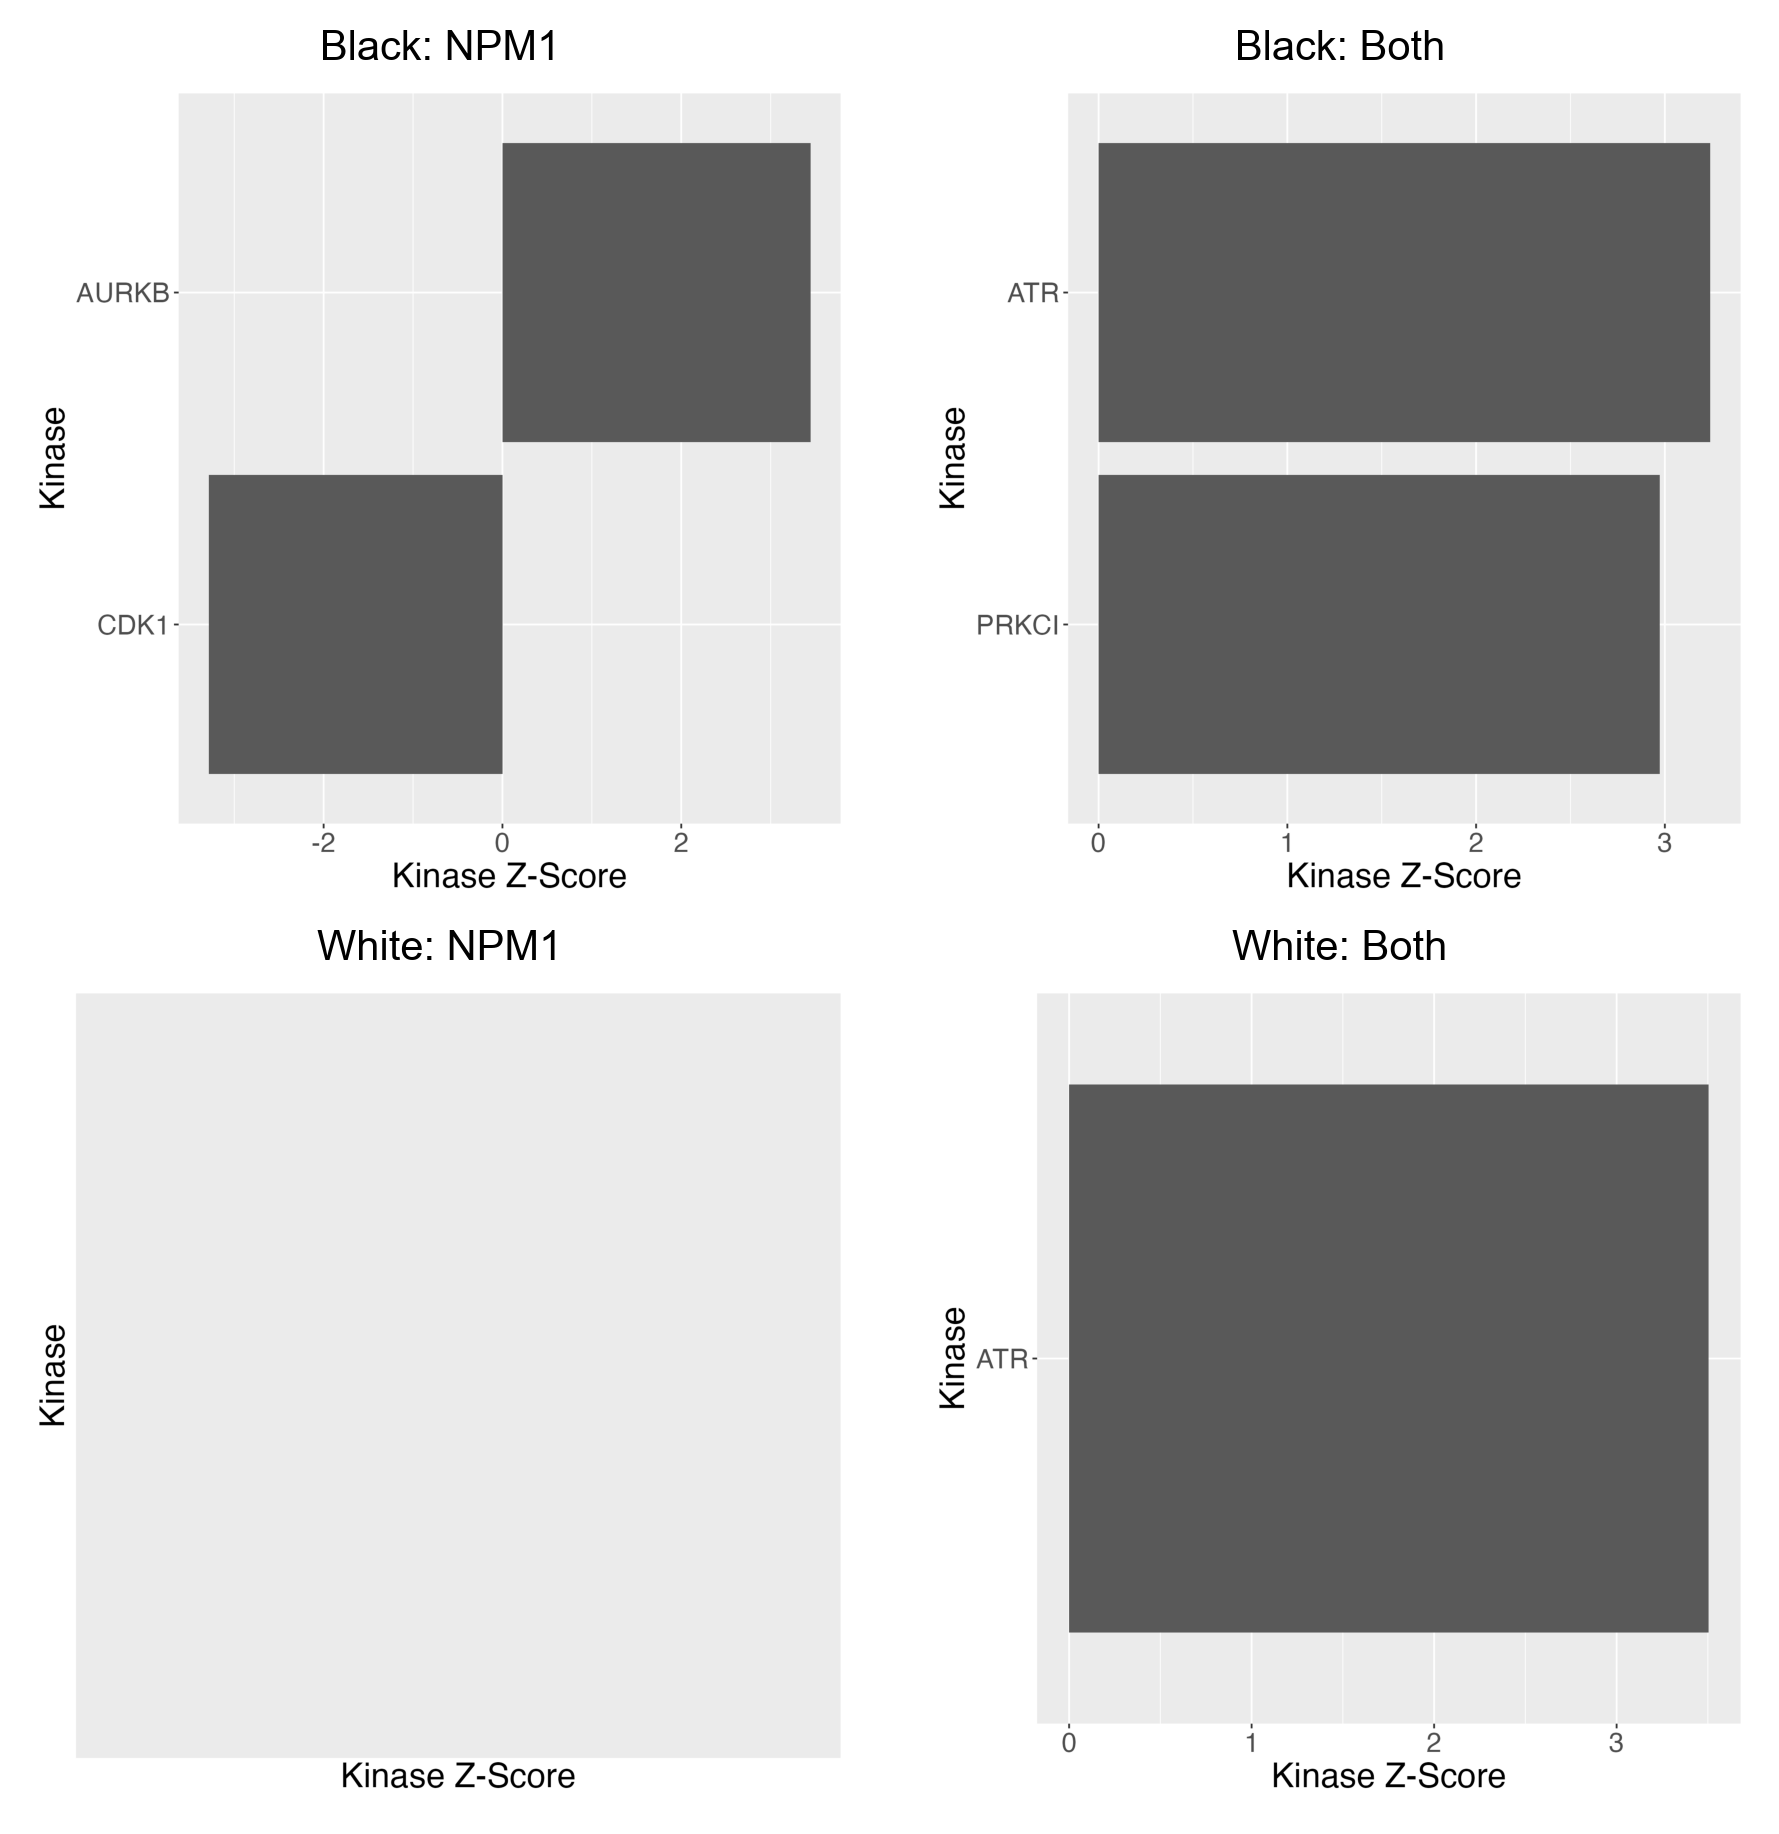

In [7]:
fig, axes = get_setup(
    2,
    2,
    fig_params={
        "figsize": (6, 6),
    }
)

black_npm1 = plt.imread(
    join(
        REPO_PATH,
        "src",
        "r",
        "ksea_mutations",
        "results",
        "Black_NPM1.png"
    )
)
black_both = plt.imread(
    join(
        REPO_PATH,
        "src",
        "r",
        "ksea_mutations",
        "results",
        "Black_Both.png"
    )
)
white_npm1 = plt.imread(
    join(
        REPO_PATH,
        "src",
        "r",
        "ksea_mutations",
        "results",
        "White_NPM1.png"
    )
)
white_both = plt.imread(
    join(
        REPO_PATH,
        "src",
        "r",
        "ksea_mutations",
        "results",
        "White_Both.png"
    )
)

axes[0, 0].imshow(black_npm1)
axes[0, 1].imshow(black_both)
axes[1, 0].imshow(white_npm1)
axes[1, 1].imshow(white_both)

for ax_row, race in enumerate(["Black", "White"]):
    for ax_col, mutation in enumerate(["NPM1", "Both"]):
        axes[ax_row, ax_col].set_axis_off()
        axes[ax_row, ax_col].set_title(f"{race}: {mutation}")

For patients with both NPM1 and FLT3-ITD mutations, we observe elevations in ATR across Black and White patients; Black patients, however, also exhibit elevations in PRKCI activity. For NPM1 mutations, however, we only observe differences in Black AML patients who have elevations in AURKB and decreases in CDK1 activity. The discordance between AURKB and CDK1 in Black NPM1+ is especially interesting as the two kinases are usually coordinated in cell cycle regulation.

### Subfigure 5b: Mean Substrate Comparisons
To validate KSEA's finding that ATR and PRKCI are elevated in activity as a result of combined NPM1/FLT3-ITD mutations, we can compare the mean expression of ATR/PRKCI substrates across race and mutations.

[syn75382181:phospho_beataml_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_beataml_batch_corrected_global_adjust.csv, skipping download.
[syn75382183:phospho_pilot_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_pilot_batch_corrected_global_adjust.csv, skipping download.


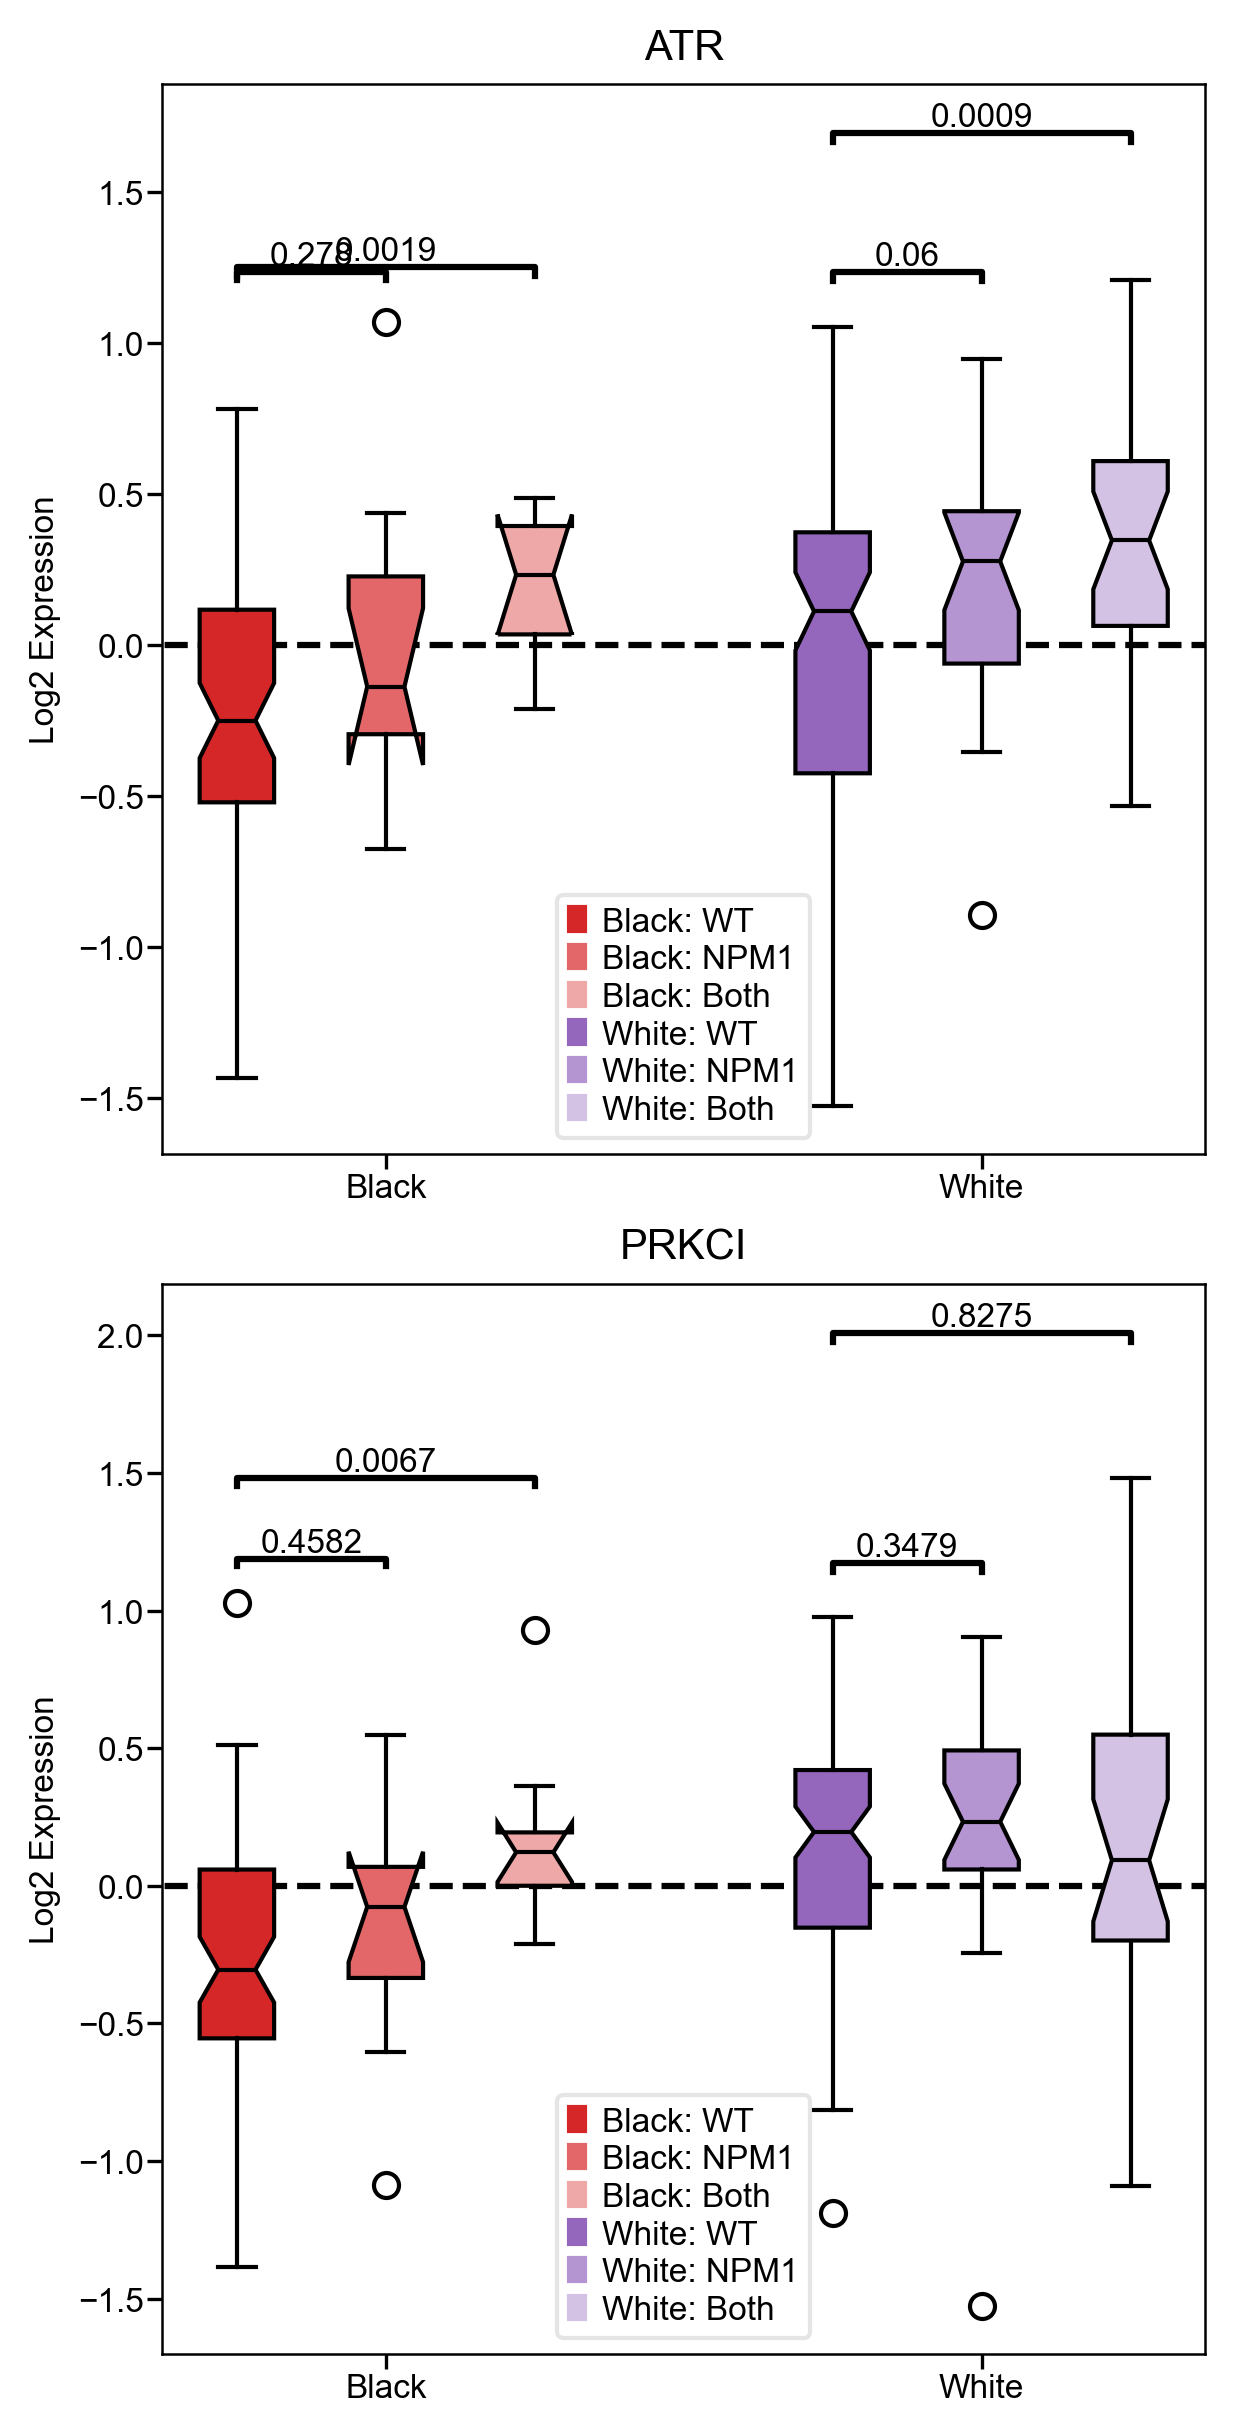

In [8]:
from figure5b import make_figure as make_figure_5b
fig_5b = make_figure_5b()

Indeed, expression of ATR substrates increases with combined NPM1/FLT3-ITD mutations across races while PRKCI substrates increase in expression only for Black AML patients with both NPM1 and FLT3-ITD mutations.

## Subfigure 5c: Substrate Evaluation
While average comparisons corroborate differential kinase activity, examining differentially-phosphorylated substrates may reveal some interesting markers. Here, we can compare phosphorylation of individual substrates across race and mutation.

[syn75382181:phospho_beataml_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_beataml_batch_corrected_global_adjust.csv, skipping download.
[syn75382183:phospho_pilot_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_pilot_batch_corrected_global_adjust.csv, skipping download.


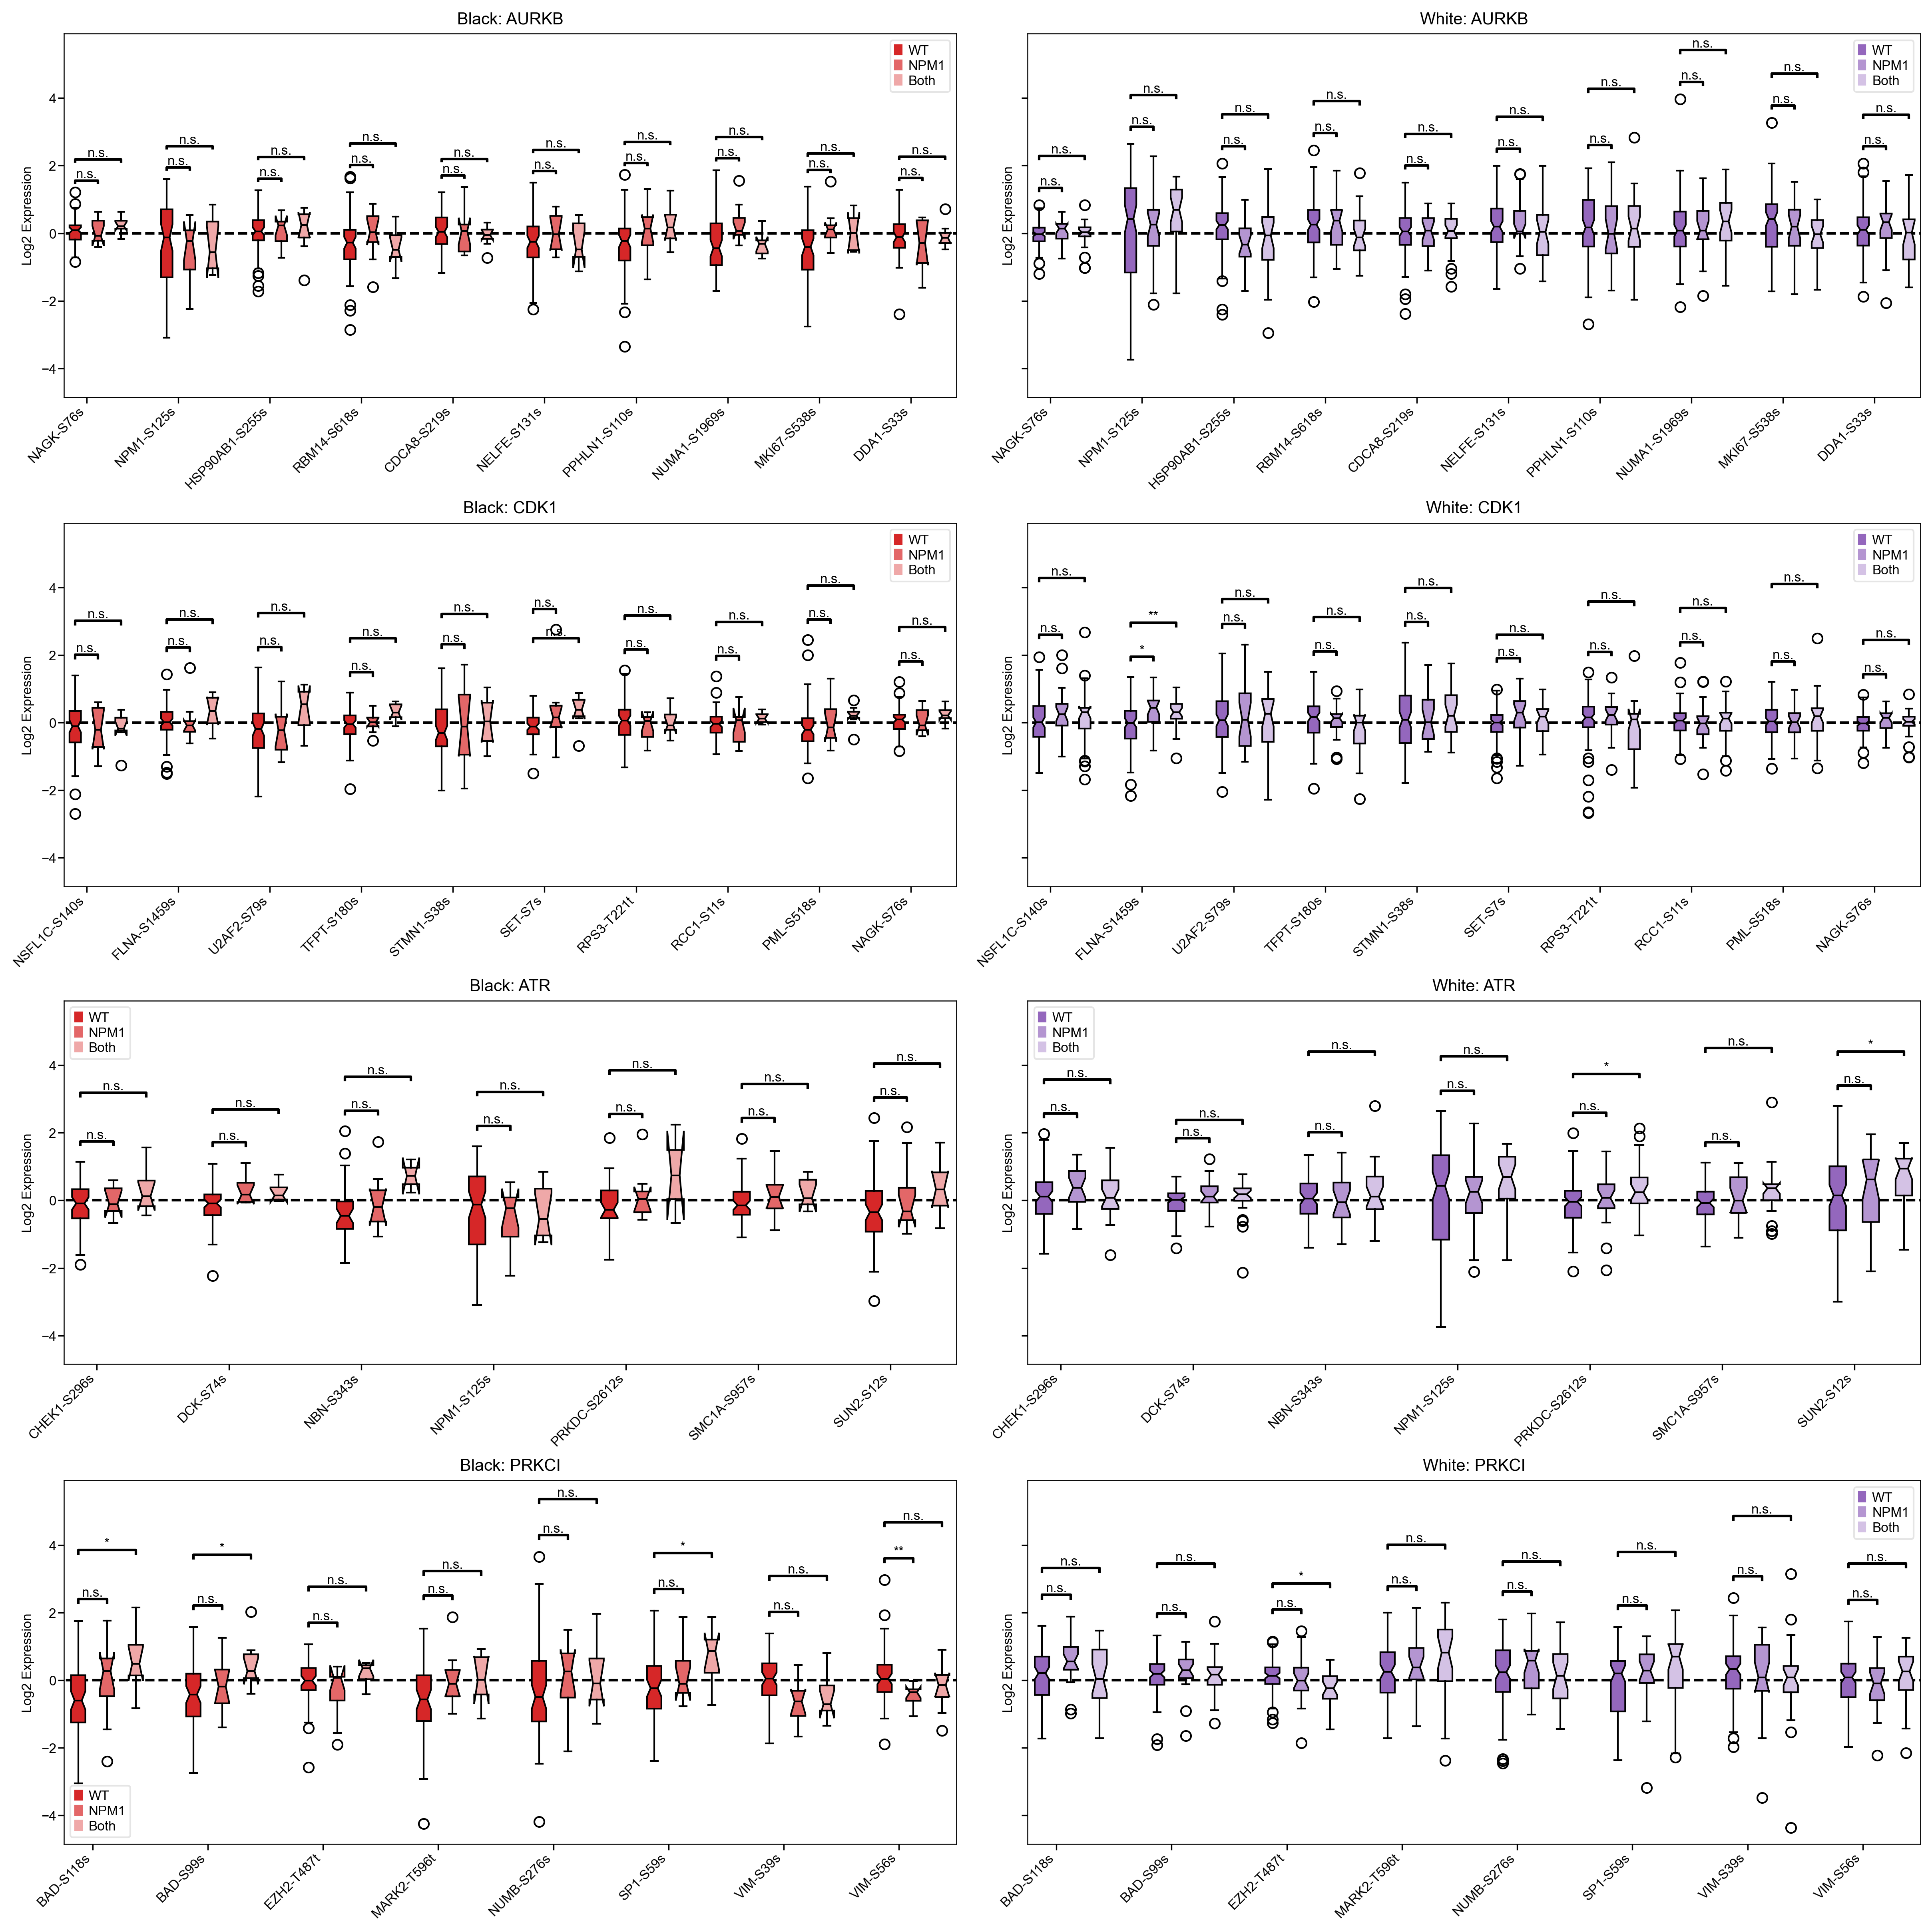

In [9]:
from figure5c import make_figure as make_figure_5c
fig_5c = make_figure_5c()

In particular, the _BAD_ sites in PRKCI for the double-mutant Black patients are interesting as these are known phosphorylation sites that inhibit _BAD_--a protein that supports apoptosis in many tumors. Likewise, these phosphorylations are associated with worse outcomes in many cancers, including AML.

## Subfigure 5d: AURKB and CDK1 dysregulation
CDK1 and AURKB are both major regulators of cell cycle progression, and their expression is often linked. KSEA indicated, however, that Black NPM1+ AML patients had increases in AURKB but decreases in CDK1 activity, indicating that there may be some dysregulation in AURKB-CDK1 interactions only in Black NPM1+ patients. To test this, we can compare correlations between AURKB and CDK1 substrates across race and mutation.

[syn75382181:phospho_beataml_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_beataml_batch_corrected_global_adjust.csv, skipping download.
[syn75382183:phospho_pilot_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_pilot_batch_corrected_global_adjust.csv, skipping download.
[syn75382181:phospho_beataml_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_beataml_batch_corrected_global_adjust.csv, skipping download.
[syn75382183:phospho_pilot_batch_corrected_global_adjust.csv]: Found existing file at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities/src/python/data/phospho_pilot_batch_corrected_global_adjust.csv, skipping download.


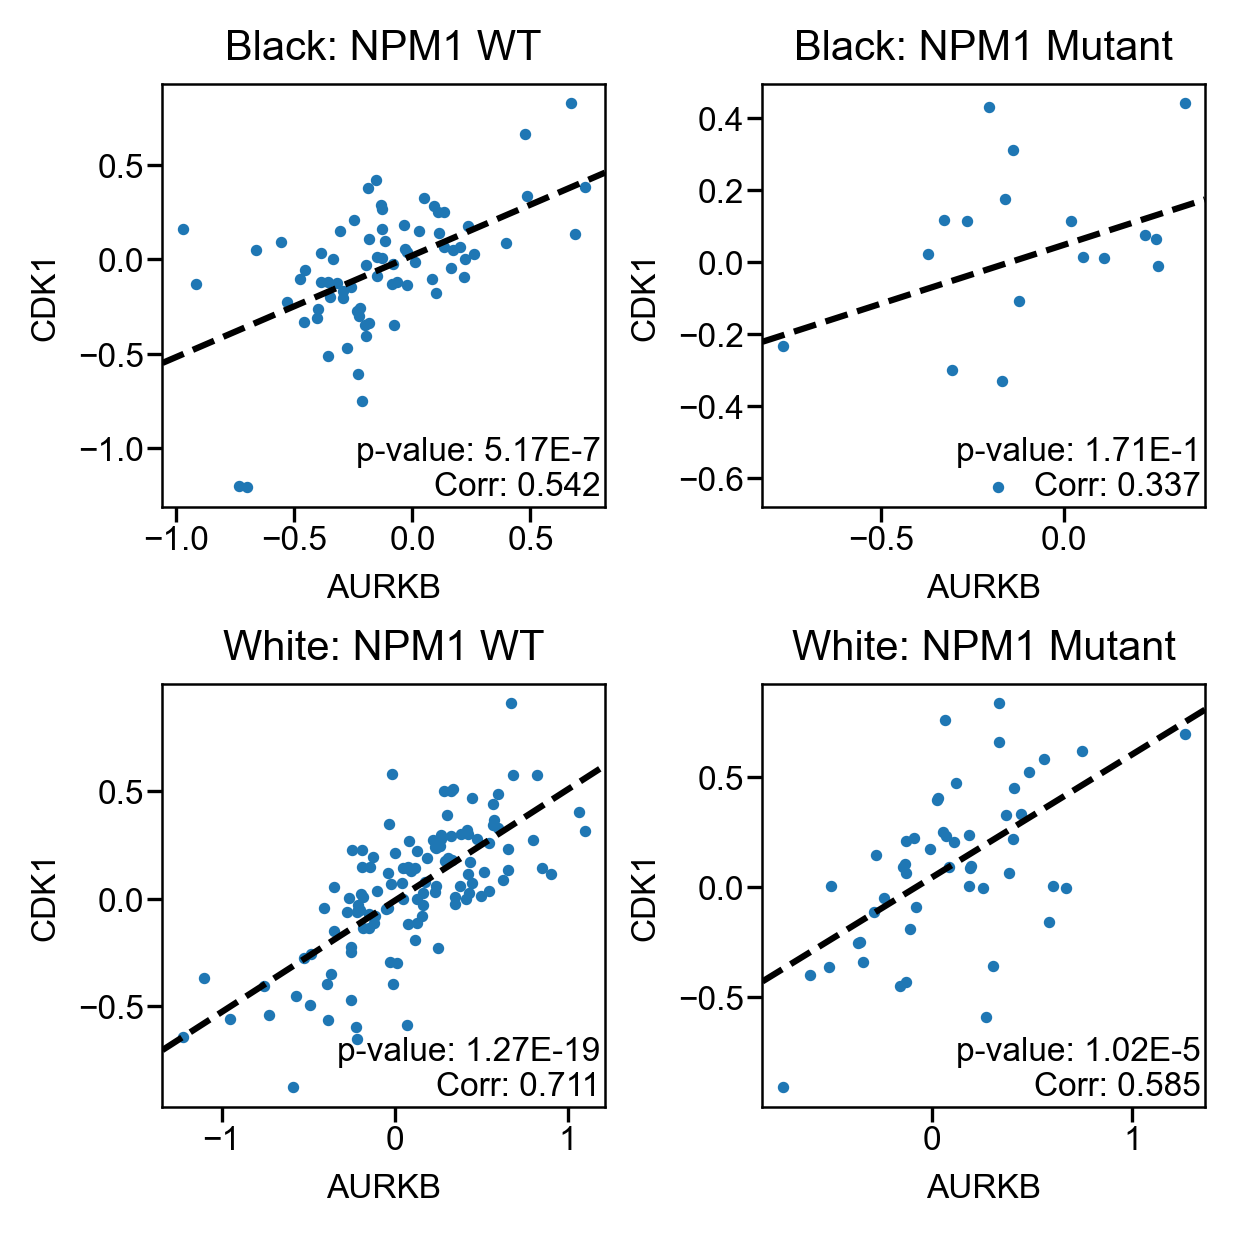

In [10]:
from figure5d import make_figure as make_figure_5d
fig_5d = make_figure_5d()

Indeed, the mean expression of AURKB and CDK1 substrates are not correlated _only_ in Black NPM1+ patients. Note, however, that this result considers FLT3-ITD+ patients too; correlation is observed between AURKB and CDK1 when only NPM1+ patients are considered, possibly due to limited sample size.